# 4. Modelling

After understanding the data, selecting the best features and cleaning those features, now we can start to create a model to predict images.

In this step we will:
- Split the data into training and validation sets
- Select the best parameters for the model using GridSearchCV
- Fit the model
- Evaluate the model using accuracy percentage and confusion matrix
- Validate overfitting using cross-validation

First, we import all the libraries we need.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn import svm
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')

# 4.1 Preparation

Next, we load in the cleaned data. This is no the `features.csv` file we created in Data Understanding which contains the raw feature extract. We import the `cleaned.csv` file which contains the cleaned features.

In [2]:
directory = "../dataset-numpy/"

dataset = pd.read_csv(os.path.join(directory, 'cleaned.csv'), delimiter=',', header=0)

dataset.describe(include='all')

,label,area_filled,area_convex,axis_major_length,axis_minor_length,feret_diameter_max,perimeter,solidity,holes,pixelsum_tr,pixelsum_ml,pixelsum_mm,pixelsum_mr,pixelsum_bl,pixelsum_bm,pixelsum_br
count,32022,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000,32022.000000
unique,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,two,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.352330,0.615487,0.503376,0.583199,0.566897,0.438399,0.424896,0.261851,0.253401,0.277581,0.279922,0.299036,0.267851,0.311162,0.347927
std,NaN,0.189474,0.148743,0.160074,0.176639,0.252383,0.153669,0.170126,0.342938,0.176371,0.171542,0.172089,0.185911,0.180424,0.175533,0.193957
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.212264,0.547126,0.391058,0.505883,0.368611,0.326641,0.303657,0.000000,0.117647,0.130435,0.130435,0.173913,0.130435,0.166667,0.208333
50%,NaN,0.306604,0.627586,0.503403,0.618700,0.559377,0.452222,0.399851,0.000000,0.235294,0.260870,0.260870,0.260870,0.217391,0.250000,0.291667
75%,NaN,0.448113,0.712644,0.616667,0.699923,0.781561,0.550496,0.520383,0.500000,0.352941,0.347826,0.391304,0.391304,0.347826,0.416667,0.458333


We split the data into:
- `X`: the features
- `y`: the target (label)

We will use `42` as the random state so we can always reproduce the same random split.

The split is done with a 90-10 ratio, 90% of the data will be used for training and 10% for validation. This is because we have a massive dataset, wth more than 3'000 images per label, so we can designate a large portion for training, and a smaller portion for validation. Even with only 10% for testing, we have a lot of images for testing, while we can give as many images as possible for training.

In [ ]:
X = dataset.loc[:, dataset.columns != 'label'] # Features
y = dataset.loc[:, dataset.columns == 'label'] # Target

rnd_state = 42 # Random state for reproducibility

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=rnd_state)

## 4.2 Model Creation and Fitting

Now we aim to get the best parameters for our model, SVM.

We will use `GridSearchCV` to find the best parameters for the model. We won't be using RandomizedSearchCV because we want to test all possible combinations of parameters, for parameters we handpicked.

We will test against the following parameters [1]:
- `C`: Regularization parameter. We will select small values to avoid overfitting. C is the penalty parameter of the error term. It controls the trade off between smooth decision boundary and classifying the training points correctly. The larger the C, the more the model will choose a smaller-margin hyperplane that correctly classifies all points, which may lead to overfitting.
- `kernel`: We will test all possible kernels. The kernel function is used to map the original dataset (linear/nonlinear) into a higher dimensional space in which it is easier to classify the data points (drawing a hyperplane).
- `degree`: Degree of the polynomial kernel function. We will use small values to avoid overfitting. This parameter is used only for the polynomial kernel.
- `gamma`: The higher the gamma value it tries to exactly fit the training data set. This will cause over-fitting problems. We will use small values to avoid overfitting.

We will use a cross-validation of 3 folds to avoid overfitting. We only use 3, and not 5 or 10, because we have a large dataset.

In [4]:
parameters = {
    'C': [0.1, 1],
    'degree': [1, 2, 4],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': [0.1, 1],
}

testing_svm = svm.SVC()

clf = GridSearchCV(testing_svm, parameters, cv=3, scoring='accuracy', n_jobs=os.cpu_count())
clf.fit(X_train, y_train.values.ravel())

print("Best parameters set found on development set:")
print(clf.best_params_)

Best parameters set found on development set:
{'C': 1, 'degree': 4, 'gamma': 1, 'kernel': 'poly'}


The above print shows the best parameters for the SVM model according to the GridSearchCV. We will use these parameters to fit the model by passing these parameters automatically to the model.

Below we fit the model. We will use multiprocessing to speed up the process.

In [5]:
clf = svm.SVC(**clf.best_params_)

accuracy_scores = cross_val_score(clf, X_train, y_train.values.ravel(), n_jobs=os.cpu_count())

clf.fit(X_train, y_train)

SVC(C=1, degree=4, gamma=1, kernel='poly')

## 4.3 Evaluation

### 4.3.1 Accuracy and Confusion

We will create a confusion matrix for each label. The goal is to determine which images the model had trouble predicting, and which images the model predicted correctly. Confusion matrix also shows what label got confused with what label.

On the left, we see the actual labe, and on the bottom, we see the predicted label. The diagonal shows the correct predictions, while the off-diagonal shows the incorrect predictions.

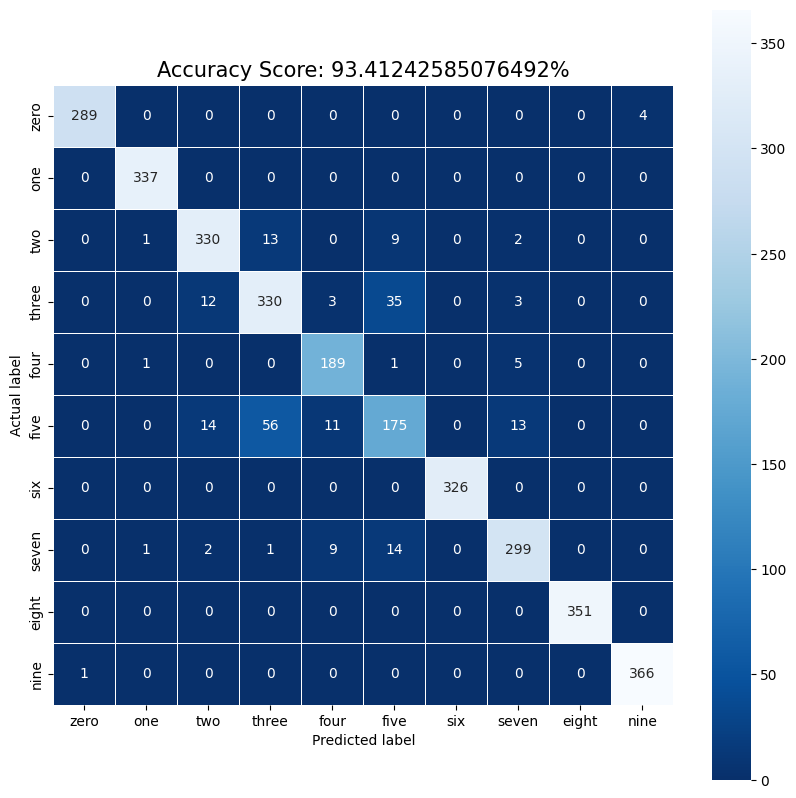

In [6]:
y_pred = clf.predict(X_test)

labels = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine'] # used to make sure the confusion matrix is in the correct order

cm = confusion_matrix(y_test, y_pred, labels=labels)

score = accuracy_score(y_test, y_pred)*100

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", linewidths=.5, square=True, cmap='Blues_r', xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Accuracy Score: {0}%'.format(score), size=15)
plt.show()


**Our overall score was 93% accuracy!**

This means, we met the business goal of minimum accuracy target of 80% or higher, and the desired 90% accuracy was also achieved.

We can conclude:
- Label `five` got confused the most. This makes sense as this is one of the the most complex label. They have no holes, and both curves, straight lines, and edges.
- Label `eight` got 100% correct predictions. This is the simplest label, with only one curve and the most holes, so this makes sense.
- Label `one` got always predicted correctly.
- Interestingly, label `four` did not get confused too often, even though it is a more complex shape like `five`, however, label `three` has more confusion, which was not expected (got confused with label `five` the most).

To improve the detection, next time we can:
- Remove more outliers (be more strict with the cleaning)
- Use an other model (like `RandomForest`, or `KNN`)
- Collect more smart (custom) features

### 4.3.2 Cross-Validation for Overfitting

Five folds are made in total. Accuracy score is measured for each fold. Each fold should not deffer by more than 10% (as per the business goal).

The maximum difference and the standard deviation between all the folds are calculated. The smaller the difference, the less overfitting the model is. If each fold produces the same accuracy, it means that the model is not overfitting.

In [7]:
# Print the individual scores to see if there are extreme differences
for fold, score in enumerate(accuracy_scores):
    print(f"Fold {fold + 1} - Accuracy score: {score}")
print()

# Print the difference between the smallest and largest score
score_difference = max(accuracy_scores) - min(accuracy_scores)
print(f"Maximum difference between accuracy scores {score_difference:.2f}")

# Print the standard deviation to check the variability of the model
deviation = np.std(accuracy_scores)
print(f"Standard Deviation of accuracy scores: {deviation:.2f}")

Fold 1 - Accuracy score: 0.9288688410825815
Fold 2 - Accuracy score: 0.9330326162387231
Fold 3 - Accuracy score: 0.9340735600277585
Fold 4 - Accuracy score: 0.9358084663428174
Fold 5 - Accuracy score: 0.9328474752732951

Maximum difference between accuracy scores 0.01
Standard Deviation of accuracy scores: 0.00


As we can see, we consistently got accuracy scores above 90% for each folds.

Since the maximum accuracy difference is only 0.01% and the standard deviation is 0, we can confidently say that the model is **not overfitting**.

Finally, we save the model to a file so we can use it later using a memory dump.

In [8]:
directory = "../classifiers/" 
path = os.path.join(directory, 'model.pkl')

with open(path, 'wb') as file:
    pickle.dump(clf, file)

## References

[1] P. Shrestha, “Tuning SVM hyperparameters: Making your classifier shine like a pro!,” Medium, Nov. 16, 2024. [Online]. Available: https://medium.com/@prayushshrestha89/tuning-svm-hyperparameters-making-your-classifier-shine-like-a-pro-8673639ddb16 (accessed Mar. 09, 2025).